# 퍼셉트론

In [2]:
import numpy as np

In [3]:
# 입력값 x1 = 1, x2 = 0
x = np.array([1, 0])
# 가중치 w
w = np.array([0.6, 0.4])
# 편향
b = -0.5

# z 값 = 가중합 + 편향
z = np.dot(w, x) + b

In [4]:
# 시그모이드 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [ ]:
# 시그모이드(z)가 0.5보다 큰 경우 1
sigmoid(z)

np.float64(0.5249791874789399)

C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\739744295.py:13: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\739744295.py:13: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RookieFit\AppData\Local\Temp\ipykernel_6332\739744295.py:13: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\RookieFit\p1-data\c3-deep-learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\RookieFit\p1-data\c3-deep-learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\RookieFit\

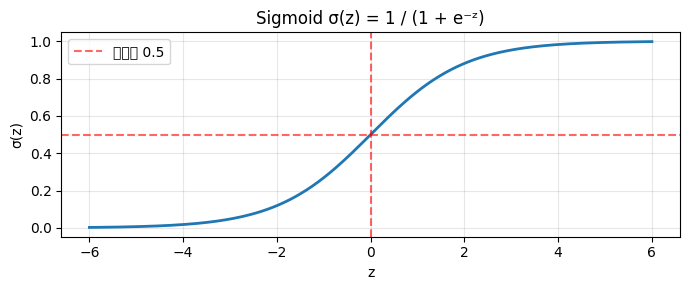

In [6]:
import matplotlib.pyplot as plt

z_range = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 3))
plt.plot(z_range, sigmoid(z_range), lw=2)
plt.axhline(0.5, color='r', linestyle='--', alpha=0.6, label='임계값 0.5')
plt.axvline(0,   color='r', linestyle='--', alpha=0.6)
plt.title('Sigmoid σ(z) = 1 / (1 + e⁻ᶻ)')
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# 퍼셉트론 함수
def perceptron(x, w, b, threshold=0.5):
    z = np.dot(w, x) + b
    a = sigmoid(z)
    predict = int(a > threshold) # 임계치보다 크면 1, 작으면 0
    return predict, a, z


In [ ]:
pred, a, z = perceptron(x, w, b)


1

# 진리표

In [10]:
# AND 게이트
w_and = np.array([1.0, 1.0])
b_and = -1.5

inputs  = [(0,0), (0,1), (1,0), (1,1)]
targets = [  0,     0,     0,     1  ]

print("AND 게이트  (w=[1,1], b=-1.5)")
print(f"{'x1':>3} {'x2':>3} │ {'z':>6}  {'σ(z)':>6}  {'예측':>4}  {'정답':>4}  {'✓/✗':>4}")
print("─" * 45)
for (x1, x2), t in zip(inputs, targets):
    pred, a, z = perceptron(np.array([x1, x2]), w_and, b_and)
    ok = "✓" if pred == t else "✗"
    print(f"  {x1}   {x2}  │ {z:>6.1f}  {a:>6.3f}  {pred:>4}  {t:>4}  {ok:>4}")

AND 게이트  (w=[1,1], b=-1.5)
 x1  x2 │      z    σ(z)    예측    정답   ✓/✗
─────────────────────────────────────────────
  0   0  │   -1.5   0.182     0     0     ✓
  0   1  │   -0.5   0.378     0     0     ✓
  1   0  │   -0.5   0.378     0     0     ✓
  1   1  │    0.5   0.622     1     1     ✓


In [12]:
# OR 게이트
w_or = np.array([1.0, 1.0])
b_or = -0.5

inputs  = [(0,0), (0,1), (1,0), (1,1)]
targets = [  0,     1,     1,     1  ]

print("OR 게이트  (w=[1,1], b=-0.5)")
print(f"{'x1':>3} {'x2':>3} │ {'z':>6}  {'σ(z)':>6}  {'예측':>4}  {'정답':>4}  {'✓/✗':>4}")
print("─" * 45)
for (x1, x2), t in zip(inputs, targets):
    pred, a, z = perceptron(np.array([x1, x2]), w_or, b_or)
    ok = "✓" if pred == t else "✗"
    print(f"  {x1}   {x2}  │ {z:>6.1f}  {a:>6.3f}  {pred:>4}  {t:>4}  {ok:>4}")

OR 게이트  (w=[1,1], b=-0.5)
 x1  x2 │      z    σ(z)    예측    정답   ✓/✗
─────────────────────────────────────────────
  0   0  │   -0.5   0.378     0     0     ✓
  0   1  │    0.5   0.622     1     1     ✓
  1   0  │    0.5   0.622     1     1     ✓
  1   1  │    1.5   0.818     1     1     ✓


In [13]:
# 가중치와 편향 조합이 학습된 지식이다

In [ ]:
# b 값에 따른 활성화 기준 변화
print("편향에 따른 σ(z) at x=[1,1]:")
for b_val in [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5]:
    z = 1+1+b_val   # w=[1,1], x=[1,1] → z = 2+b
    a = sigmoid(z)
    print(f"  b={b_val:+.1f} → z={z:+.1f} → σ={a:.3f}  {'← 활성화' if a>=0.5 else ''}")

# b가 작을수록 더 까다로운 조건에 활성화되고,
# b가 클수록 쉽게 활성화가 된다.

편향에 따른 σ(z) at x=[1,1]:
  b=-2.0 → z=+0.0 → σ=0.500  ← 활성화
  b=-1.5 → z=+0.5 → σ=0.622  ← 활성화
  b=-1.0 → z=+1.0 → σ=0.731  ← 활성화
  b=-0.5 → z=+1.5 → σ=0.818  ← 활성화
  b=+0.0 → z=+2.0 → σ=0.881  ← 활성화
  b=+0.5 → z=+2.5 → σ=0.924  ← 활성화
